In [66]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
df = pd.read_csv('/content/train.csv')

In [69]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [70]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [71]:
df = df.drop(['Pclass','PassengerId','Name','SibSp','Cabin','Sex','Parch','Embarked','Ticket'],axis = 1)

In [72]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [73]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [74]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
X_train

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


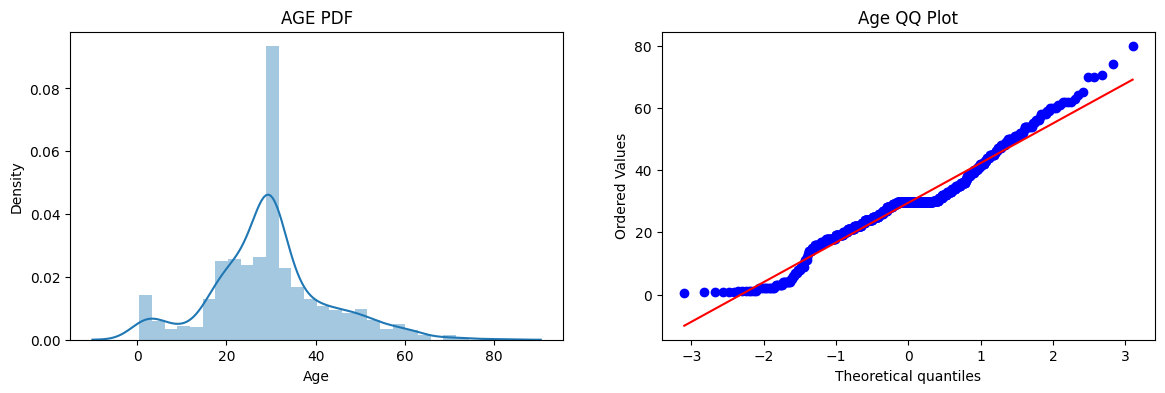

In [76]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title("AGE PDF")

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ Plot')
plt.show()

Text(0.5, 1.0, 'Fare QQ Plot')

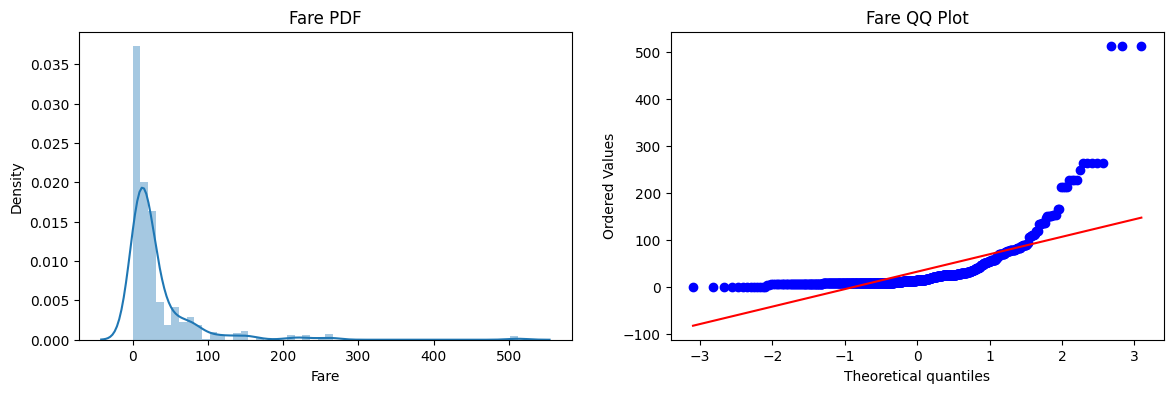

In [77]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')

In [78]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1= clf2.predict(X_test)

print(f'Accuracy LR : {accuracy_score(y_test,y_pred)}')
print(f'Accuracy DT : {accuracy_score(y_test,y_pred1)}')

Accuracy LR : 0.6480446927374302
Accuracy DT : 0.6871508379888268


In [79]:
trf = FunctionTransformer(func=np.log1p)

In [80]:
X_train_trans = trf.fit_transform(X_train)
X_test_trans = trf.fit_transform(X_test)

In [83]:
clf3= LogisticRegression()
clf4 = DecisionTreeClassifier()

clf3.fit(X_train_trans,y_train)
clf4.fit(X_train_trans,y_train)

y_pred = clf3.predict(X_test_trans)
y_pred1= clf4.predict(X_test_trans)

print(f'Accuracy LR : {accuracy_score(y_test,y_pred)}')
print(f'Accuracy DT : {accuracy_score(y_test,y_pred1)}')

Accuracy LR : 0.6815642458100558
Accuracy DT : 0.6703910614525139


In [84]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.658876404494382


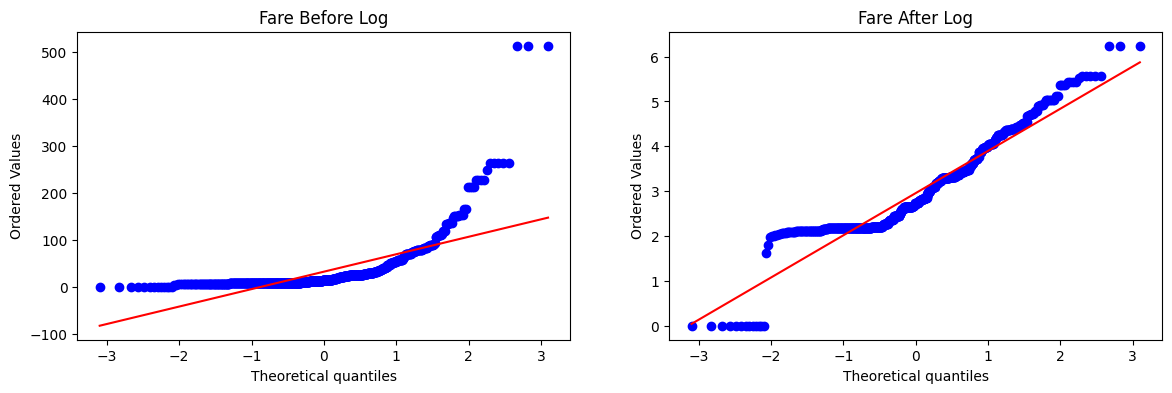

In [85]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(X_train_trans['Fare'],dist='norm',plot=plt)
plt.title("Fare After Log")
plt.show()

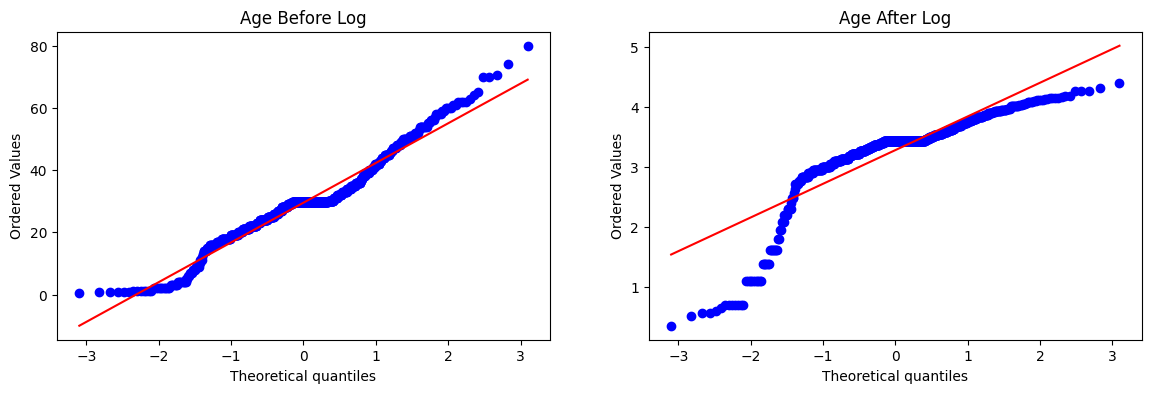

In [87]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_trans['Age'],dist='norm',plot=plt)
plt.title('Age After Log')
plt.show()

**What we have observed here is like our Fare transformation was good and effects are pretty impressive but the things is about the age , age has not performed well because we have applied on age column but it doesn't requires that it was not skewed enough so that the thing we have to change the age remains the same as it is.**